In [1]:
# 04_calibration.ipynb
# Purpose: compute calibration diagnostics for final lightweight model (Top-7).
# Run cells in order. Outputs saved under ../figures and ../artifacts.

In [1]:
# Cell 1: imports & config
import os, json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
import sys
sys.path.append("..")
from src.transforms import select_cols_top7

%matplotlib inline

# paths (adjust if needed)
MODEL_PATH = "../artifacts/final_lightweight_model_k7_clean.joblib"   # calibrated model wrapper expected
DATA_PATH  = "../data/heart_uci.csv"
OUT_DIR    = "../figures"
ART_DIR    = "../artifacts"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)

print("Model:", MODEL_PATH)
print("Data:", DATA_PATH)

Model: ../artifacts/final_lightweight_model_k7_clean.joblib
Data: ../data/heart_uci.csv


In [9]:
# Cell 2: load data and create holdout
df = pd.read_csv(DATA_PATH)
# convert to binary target
if 'num' in df.columns:
    df['num'] = (df['num'] > 0).astype(int)

X = df.drop(columns=['num'])
y = df['num'].values

# If you have a saved holdout split, use it; otherwise create holdout reproducibly
# We create a holdout 20% split for calibration analysis.
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train / Hold sizes:", X_train.shape[0], X_hold.shape[0])

Train / Hold sizes: 736 184


In [11]:
# Cell 3: load calibrated model and get internal (uncalibrated) pipeline
model = joblib.load(MODEL_PATH)
print("Loaded model type:", type(model))

# We expect a CalibratedClassifierCV wrapper containing .estimator (pipeline).
if hasattr(model, "estimator"):
    calibrated_model = model
    base_pipeline = model.estimator  # contains preprocessing + XGB (uncalibrated)
    print("Found calibrated wrapper with inner pipeline.")
else:
    # If not wrapper, assume model is pipeline already (uncalibrated)
    calibrated_model = None
    base_pipeline = model
    print("No calibrated wrapper found; using pipeline as base_pipeline (uncalibrated).")

print("Pipeline steps (inner):", [name for name,_ in base_pipeline.steps])

Loaded model type: <class 'sklearn.calibration.CalibratedClassifierCV'>
Found calibrated wrapper with inner pipeline.
Pipeline steps (inner): ['preprocessor', 'selector', 'model']


In [13]:
# Cell 4: get probabilities and compute metrics (calibrated vs uncalibrated)
# Calibrated probabilities
if calibrated_model is not None:
    probs_cal = calibrated_model.predict_proba(X_hold)[:,1]
else:
    probs_cal = base_pipeline.predict_proba(X_hold)[:,1]  # fallback (treated as "calibrated" if no wrapper)

# Uncalibrated probabilities (from inner pipeline)
probs_uncal = base_pipeline.predict_proba(X_hold)[:,1]

# Basic metrics
metrics = {
    "n_hold": int(len(y_hold)),
    "roc_calibrated": float(roc_auc_score(y_hold, probs_cal)),
    "ap_calibrated": float(average_precision_score(y_hold, probs_cal)),
    "brier_calibrated": float(brier_score_loss(y_hold, probs_cal)),
    "roc_uncalibrated": float(roc_auc_score(y_hold, probs_uncal)),
    "ap_uncalibrated": float(average_precision_score(y_hold, probs_uncal)),
    "brier_uncalibrated": float(brier_score_loss(y_hold, probs_uncal))
}
print(pd.Series(metrics))
# save metrics (partial)
json.dump(metrics, open(os.path.join(ART_DIR, "calibration_metrics_k7.json"), "w"), indent=2)
print("Saved metrics to", os.path.join(ART_DIR, "calibration_metrics_k7.json"))

n_hold                184.000000
roc_calibrated          0.924617
ap_calibrated           0.928807
brier_calibrated        0.110386
roc_uncalibrated        0.921808
ap_uncalibrated         0.924298
brier_uncalibrated      0.110484
dtype: float64
Saved metrics to ../artifacts\calibration_metrics_k7.json


Saved calibration figure to ../figures\calibration_curve_uncal_vs_cal.png


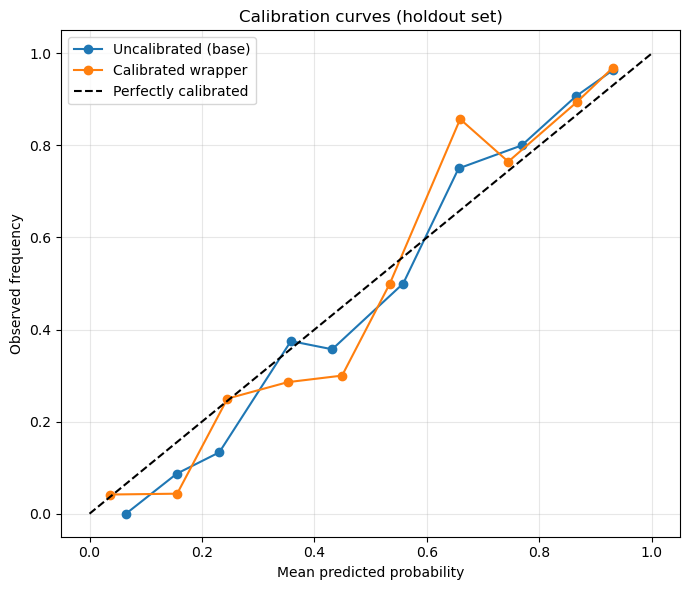

In [16]:
# Cell 5: calibration curves (reliability diagram) for both models
from sklearn.utils import check_array

def plot_calibration(y_true, prob_list, labels, n_bins=10, out_path=None):
    plt.figure(figsize=(7,6))
    for probs, label in zip(prob_list, labels):
        prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
        plt.plot(prob_pred, prob_true, marker='o', label=label)
    plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Calibration curves (holdout set)")
    plt.legend()
    plt.grid(alpha=0.3)
    if out_path:
        plt.tight_layout()
        plt.savefig(out_path, dpi=250)
        print("Saved calibration figure to", out_path)
    plt.show()

plot_calibration(y_hold, [probs_uncal, probs_cal], ["Uncalibrated (base)", "Calibrated wrapper"], n_bins=10,
                 out_path=os.path.join(OUT_DIR, "calibration_curve_uncal_vs_cal.png"))

In [18]:
# Cell 6: compute ECE and calibration table by bin for both models
def calibration_table(y_true, probs, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": probs})
    df["bin"] = pd.cut(df["p"], bins=np.linspace(0,1,n_bins+1), include_lowest=True)
    table = df.groupby("bin").agg(n=("y","size"),
                                  mean_pred=("p","mean"),
                                  frac_pos=("y","mean")).reset_index()
    table["abs_error"] = (table["mean_pred"] - table["frac_pos"]).abs()
    return table

def expected_calibration_error(table):
    n = table["n"].sum()
    return (table["n"] * table["abs_error"]).sum() / n

tbl_uncal = calibration_table(y_hold, probs_uncal, n_bins=10)
tbl_cal   = calibration_table(y_hold, probs_cal, n_bins=10)

ece_uncal = expected_calibration_error(tbl_uncal)
ece_cal   = expected_calibration_error(tbl_cal)

print("ECE uncalibrated:", ece_uncal)
print("ECE calibrated:  ", ece_cal)

# Save tables
tbl_uncal.to_csv(os.path.join(ART_DIR,"calib_table_uncal.csv"), index=False)
tbl_cal.to_csv(os.path.join(ART_DIR,"calib_table_cal.csv"), index=False)
json.dump({"ece_uncalibrated": float(ece_uncal), "ece_calibrated": float(ece_cal)}, open(os.path.join(ART_DIR,"calibration_ece.json"),"w"), indent=2)
print("Saved calibration tables and ECE.")

ECE uncalibrated: 0.05667235864245372
ECE calibrated:   0.05064135974516041
Saved calibration tables and ECE.


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_1244\766175234.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby("bin").agg(n=("y","size"),
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_1244\766175234.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby("bin").agg(n=("y","size"),


Refit calibrator time (s): 0.8834404945373535
roc_recalibrated      0.924617
ap_recalibrated       0.928807
brier_recalibrated    0.110386
dtype: float64
Saved calibration figure to ../figures\calibration_curve_three.png


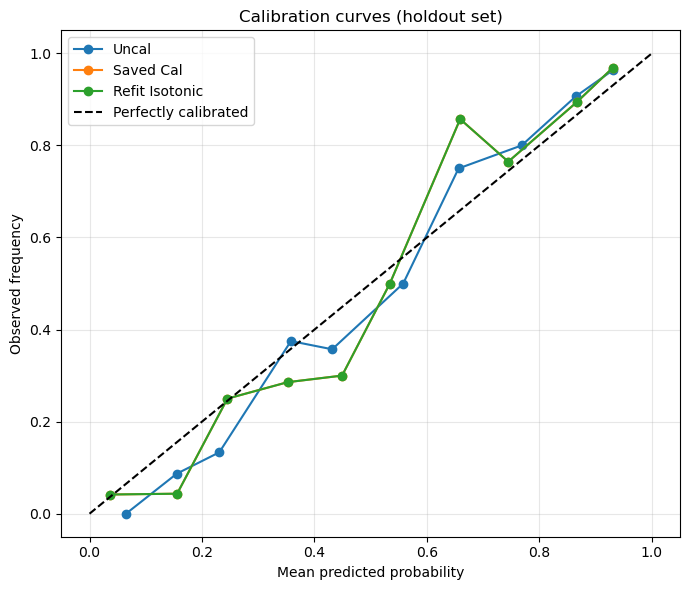

Saved recalibrator to artifacts.


In [20]:
# Cell 7: optional — fit a new isotonic calibrator on the base pipeline (if you want to test re-calibration)
from sklearn.calibration import CalibratedClassifierCV
import time
t0 = time.time()
calibrator = CalibratedClassifierCV(base_pipeline, cv=5, method='isotonic')  # or 'sigmoid'
calibrator.fit(X_train, y_train)
t1 = time.time()
print("Refit calibrator time (s):", t1-t0)

probs_recal = calibrator.predict_proba(X_hold)[:,1]
metrics_recal = {
    "roc_recalibrated": float(roc_auc_score(y_hold, probs_recal)),
    "ap_recalibrated": float(average_precision_score(y_hold, probs_recal)),
    "brier_recalibrated": float(brier_score_loss(y_hold, probs_recal))
}
print(pd.Series(metrics_recal))

# plot comparison including this recalibrated one
plot_calibration(y_hold, [probs_uncal, probs_cal, probs_recal], ["Uncal","Saved Cal","Refit Isotonic"], n_bins=10,
                 out_path=os.path.join(OUT_DIR,"calibration_curve_three.png"))

# save recalibrator if desired
joblib.dump(calibrator, os.path.join(ART_DIR,"recalibrator_basepipeline_isotonic.joblib"))
print("Saved recalibrator to artifacts.")

In [21]:
# Cell 8: collate final metrics and print summary
final_metrics = {
    "roc_uncalibrated": metrics["roc_uncalibrated"],
    "ap_uncalibrated": metrics["ap_uncalibrated"],
    "brier_uncalibrated": metrics["brier_uncalibrated"],
    "roc_calibrated": metrics["roc_calibrated"],
    "ap_calibrated": metrics["ap_calibrated"],
    "brier_calibrated": metrics["brier_calibrated"],
    "ece_uncalibrated": float(ece_uncal),
    "ece_calibrated": float(ece_cal)
}
json.dump(final_metrics, open(os.path.join(ART_DIR,"final_calibration_summary_k7.json"), "w"), indent=2)
print("Final calibration summary saved to artifacts/final_calibration_summary_k7.json")
print(pd.Series(final_metrics))

Final calibration summary saved to artifacts/final_calibration_summary_k7.json
roc_uncalibrated      0.921808
ap_uncalibrated       0.924298
brier_uncalibrated    0.110484
roc_calibrated        0.924617
ap_calibrated         0.928807
brier_calibrated      0.110386
ece_uncalibrated      0.056672
ece_calibrated        0.050641
dtype: float64
